<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DES VENTES DE LAPAGE</h1>
</div>

### Importation des librairies

In [ ]:
#Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Chargement des fichiers

In [ ]:
#Lien permettant d'accéder à mon Google Drive ou sont stocker mes fichiers
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importation du fichier customers.csv
customers = pd.read_csv('/content/drive/MyDrive/Projet_9_Data/customers.csv', sep=";")
#Importation du fichier products.csv
products = pd.read_csv('/content/drive/MyDrive/Projet_9_Data/products.csv', sep=";")
#Importation du fichier Transactions.csv
transactions = pd.read_csv('/content/drive/MyDrive/Projet_9_Data/Transactions.csv', sep=";")

/tmp/ipykernel_4640/71004388.py:6: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('/content/drive/MyDrive/Projet_9_Data/Transactions.csv', sep=";")


## **Premières analyses des DataFrames**

In [ ]:
customers.head(5)

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [ ]:
#Ajouter l'age des clients à partir de leur années de naissance (birth)
customers['age'] = 2023 - customers['birth']
customers.head(5)

,client_id,sex,birth,age
0,c_4410,f,1967,56
1,c_7839,f,1975,48
2,c_1699,f,1984,39
3,c_5961,f,1962,61
4,c_5320,m,1943,80


In [ ]:
#Verifier qu'il n'y a pas de valeur vide
customers.isna().sum()

,0
client_id,0
sex,0
birth,0
age,0


In [ ]:
products.head(5)

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [ ]:
#Verifer qu'il n'y a pas de valeur manquantes
products.isna().sum()

,0
id_prod,0
price,0
categ,0


In [ ]:
transactions.head(5)

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [ ]:
#Verifier qu'il n'y a pas de valeur manquante
transactions.isna().sum()

,0
id_prod,361041
date,361041
session_id,361041
client_id,361041


In [ ]:
#Faire une liste avec tout les Dataframes
dfs = {
    'customers': customers,
    'products': products,
    'transactions': transactions
}

In [ ]:
# Voir les dimensions des données
print (f'Les dimensions des DataFrames sont:')
for name, df in dfs.items():
  print(f'{name} : {df.shape}')

Les dimensions des DataFrames sont:
customers : (8621, 4)
products : (3286, 3)
transactions : (1048575, 4)


In [ ]:
# j'ai beaucoup trop de ligne dans le DF transactions en comparaison au fichier CSV, vérification des dernière lignes du fichier
transactions.tail(10)

,id_prod,date,session_id,client_id
1048565,NaN,NaN,NaN,NaN
1048566,NaN,NaN,NaN,NaN
1048567,NaN,NaN,NaN,NaN
1048568,NaN,NaN,NaN,NaN
1048569,NaN,NaN,NaN,NaN
1048570,NaN,NaN,NaN,NaN
1048571,NaN,NaN,NaN,NaN
1048572,NaN,NaN,NaN,NaN
1048573,NaN,NaN,NaN,NaN
1048574,NaN,NaN,NaN,NaN


In [ ]:
# Suppression des lignes vides
transactions = transactions.dropna()
print (transactions.shape)

(687534, 4)


### Verification des types de données

In [ ]:
customers.dtypes

,0
client_id,object
sex,object
birth,int64
age,int64


In [ ]:
products.dtypes

,0
id_prod,object
price,float64
categ,int64


In [ ]:
transactions.dtypes

,0
id_prod,object
date,object
session_id,object
client_id,object


In [ ]:
# Conversion du type pour les dates
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
transactions.dtypes

/tmp/ipykernel_4640/599205206.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')


,0
id_prod,object
date,datetime64[ns]
session_id,object
client_id,object


### Fusion des trois Dataframes

In [ ]:
# Ajouter les information produits aux transactions
df_final = pd.merge(transactions, products, on='id_prod', how='left')

# Ajoutons ensuite le fichier clients
df_final = pd.merge(df_final, customers, on='client_id', how='left')

df_final.head(5)
print(f'Les dimensions du nouveau DataFrame sont : {df_final.shape}')

Les dimensions du nouveau DataFrame sont : (687534, 9)


In [ ]:
# Verifier qu'il n'y a pas de valeurs manquantes
df_final.isna().sum()

,0
id_prod,0
date,0
session_id,0
client_id,0
price,0
categ,0
sex,0
birth,0
age,0


## **Analyse des indicateurs**

### Moyenne et moyenne mobile

In [ ]:
# Affichier les resultat du chiffres d'affaire par années
ca_annuel=df_final.groupby(df_final['date'].dt.year)['price'].sum().reset_index()
ca_annuel.columns=['Année','Chiffre d affaire']

#Total
ca_total=df_final['price'].sum()

print(ca_annuel)
print(f'Le chiffre d affaire total est de {ca_total} euros')

   Année  Chiffre d affaire
0   2021         4944760.98
1   2022         6108681.81
2   2023          974220.31
Le chiffre d affaire total est de 12027663.100000003 euros


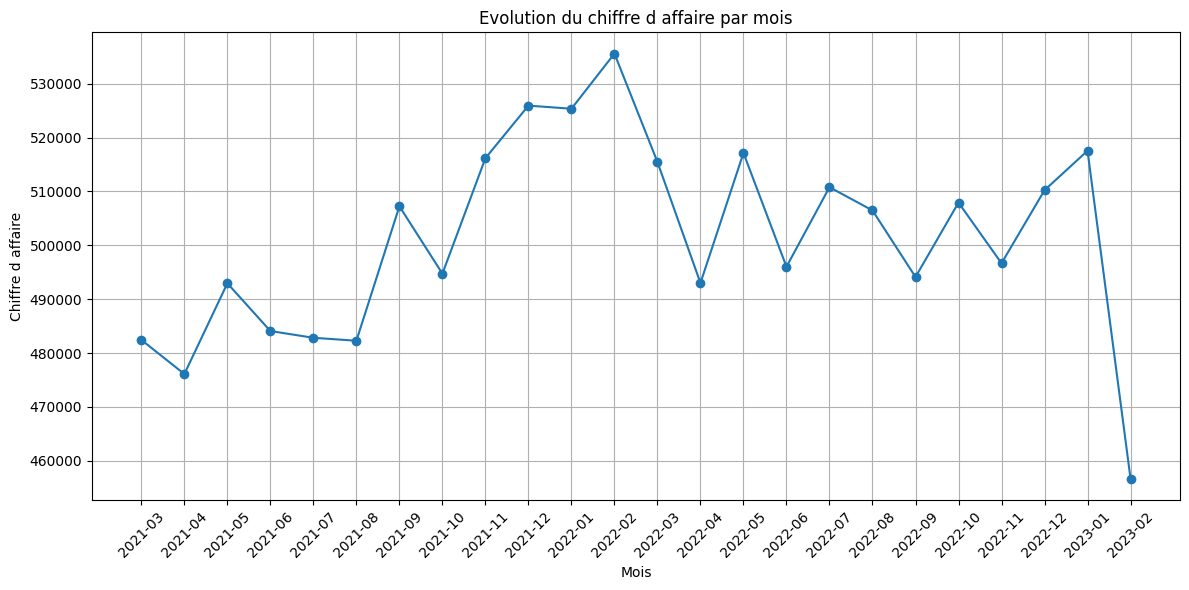

In [ ]:
#Suivi de l'évolution du chiffre d'affaire par mois

df_mois= (df_final.groupby(df_final['date'].dt.to_period('M'))['price'].sum().reset_index())
df_mois['date'] = df_mois['date'].astype(str)

plt.figure(figsize=(12,6))
plt.plot(df_mois['date'], df_mois['price'],marker='o')
plt.title('Evolution du chiffre d affaire par mois')
plt.xlabel('Mois')
plt.xticks(rotation=45)
plt.ylabel('Chiffre d affaire')
plt.grid(True)
plt.tight_layout()
plt.show()

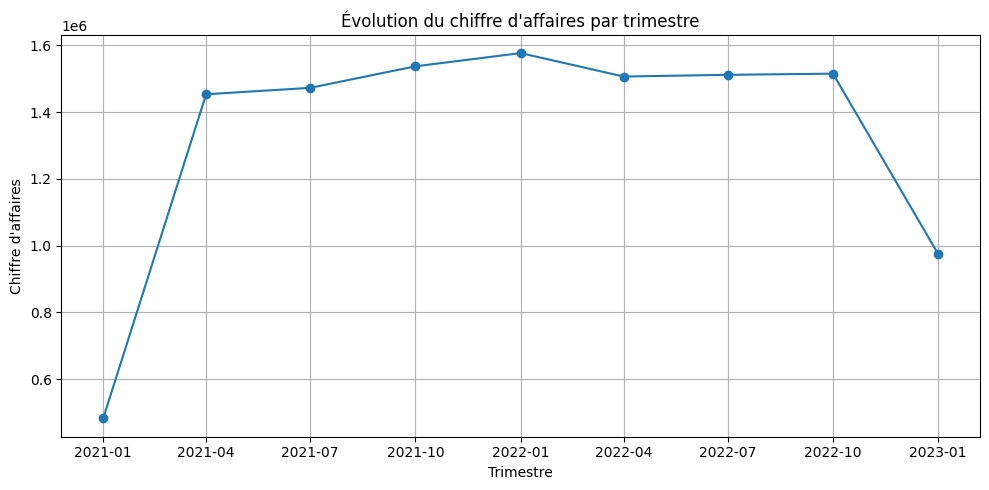

In [ ]:
# Test graphique par trimestre
df_trimestre= (df_final.groupby(df_final['date'].dt.to_period('Q'))['price'].sum().reset_index())
df_trimestre['date'] =df_trimestre['date'].dt.to_timestamp()

plt.figure(figsize=(10,5))
plt.plot(df_trimestre['date'], df_trimestre['price'], marker='o')
plt.title("Évolution du chiffre d'affaires par trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Chiffre d'affaires")
plt.grid(True)
plt.tight_layout()
plt.show()


**Une moyenne mobile est une méthode statistique qui lisse une série de données dans le temps afin de faire ressortir une tendance plus claire**. Elle sert à atténuer les variations brusques et à mieux comprendre l’évolution d’un phénomène, qu’il s’agisse de météo, d’économie ou de marchés financiers

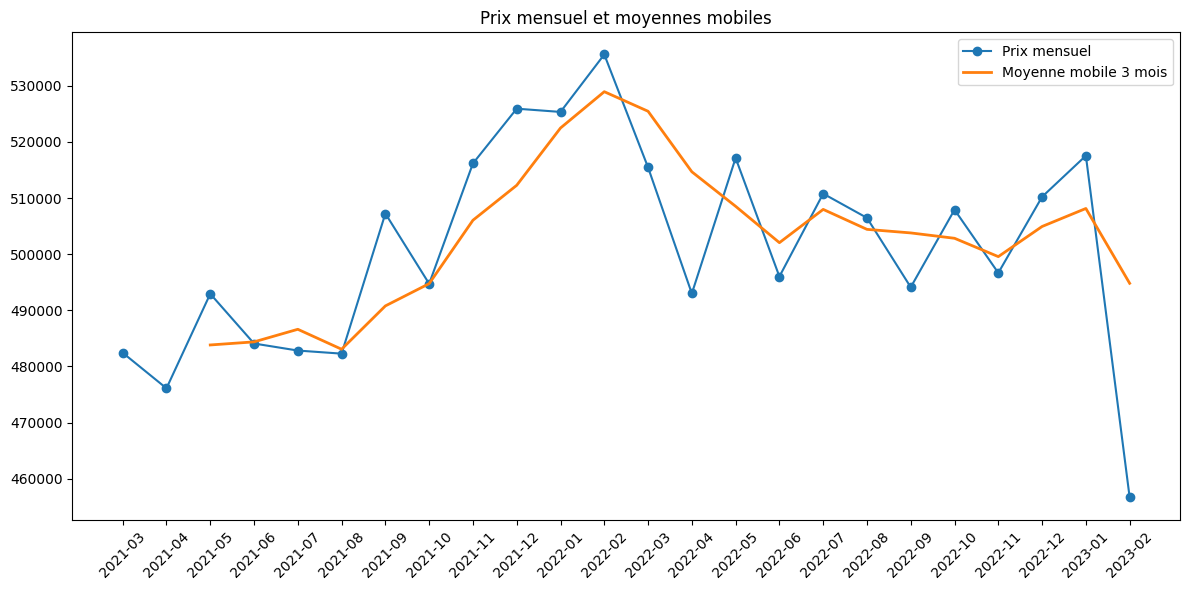

In [ ]:
# Moyenne mobile
df_mois['MA_3']=df_mois['price'].rolling(window=3).mean()

plt.figure(figsize=(12,6))

plt.plot(df_mois['date'], df_mois['price'], label='Prix mensuel', marker='o')
plt.plot(df_mois['date'], df_mois['MA_3'], label='Moyenne mobile 3 mois', linewidth=2)

plt.xticks(rotation=45)
plt.legend()
plt.title("Prix mensuel et moyennes mobiles")
plt.tight_layout()
plt.show()

Nous pouvons voir grace à la moyenne mobile une baisse après le pique en janvier-février 2022. Voyons maintenant le chiffre d'affaire par catégorie de produit.

### Chiffres d'affaires par catégories

In [ ]:
# Calcul du chiffre d'affaires par catégorie de produit
ca_par_categorie = df_final.groupby('categ')['price'].sum().reset_index()
ca_par_categorie.columns = ['Catégorie', 'Chiffre d affaire']

print("Chiffre d'affaires par catégorie de produit:")
print(ca_par_categorie)

Chiffre d'affaires par catégorie de produit:
   Catégorie  Chiffre d affaire
0          0         4419730.97
1          1         4827657.11
2          2         2780275.02


/tmp/ipykernel_4640/1685040510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Catégorie', y='Chiffre d affaire', data=ca_par_categorie, palette='viridis')


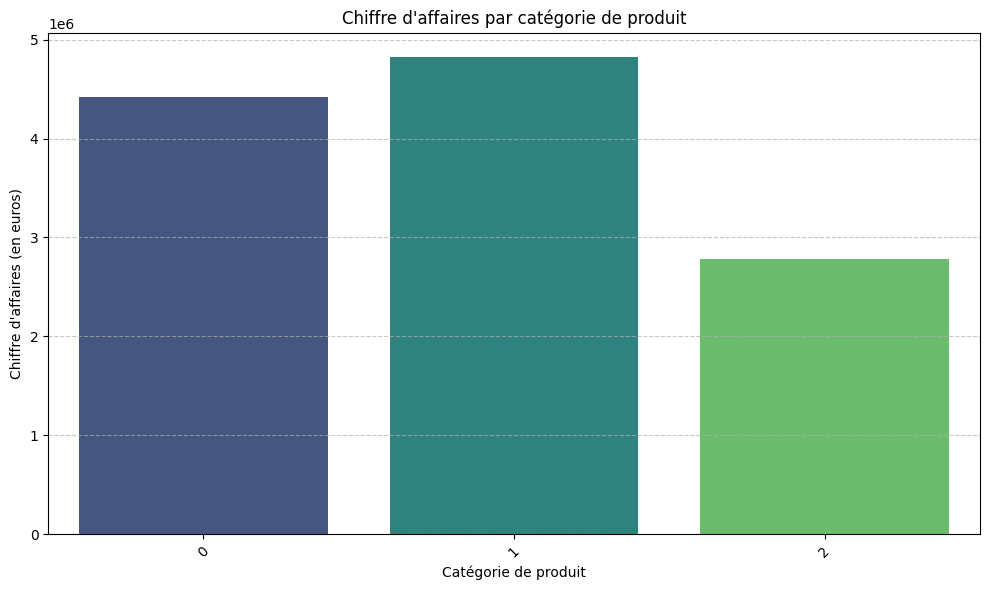

In [ ]:
# Visualisation du chiffre d'affaires par catégorie de produit
plt.figure(figsize=(10, 6))
sns.barplot(x='Catégorie', y='Chiffre d affaire', data=ca_par_categorie, palette='viridis')
plt.title("Chiffre d'affaires par catégorie de produit")
plt.xlabel("Catégorie de produit")
plt.ylabel("Chiffre d'affaires (en euros)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Figure size 1500x700 with 0 Axes>

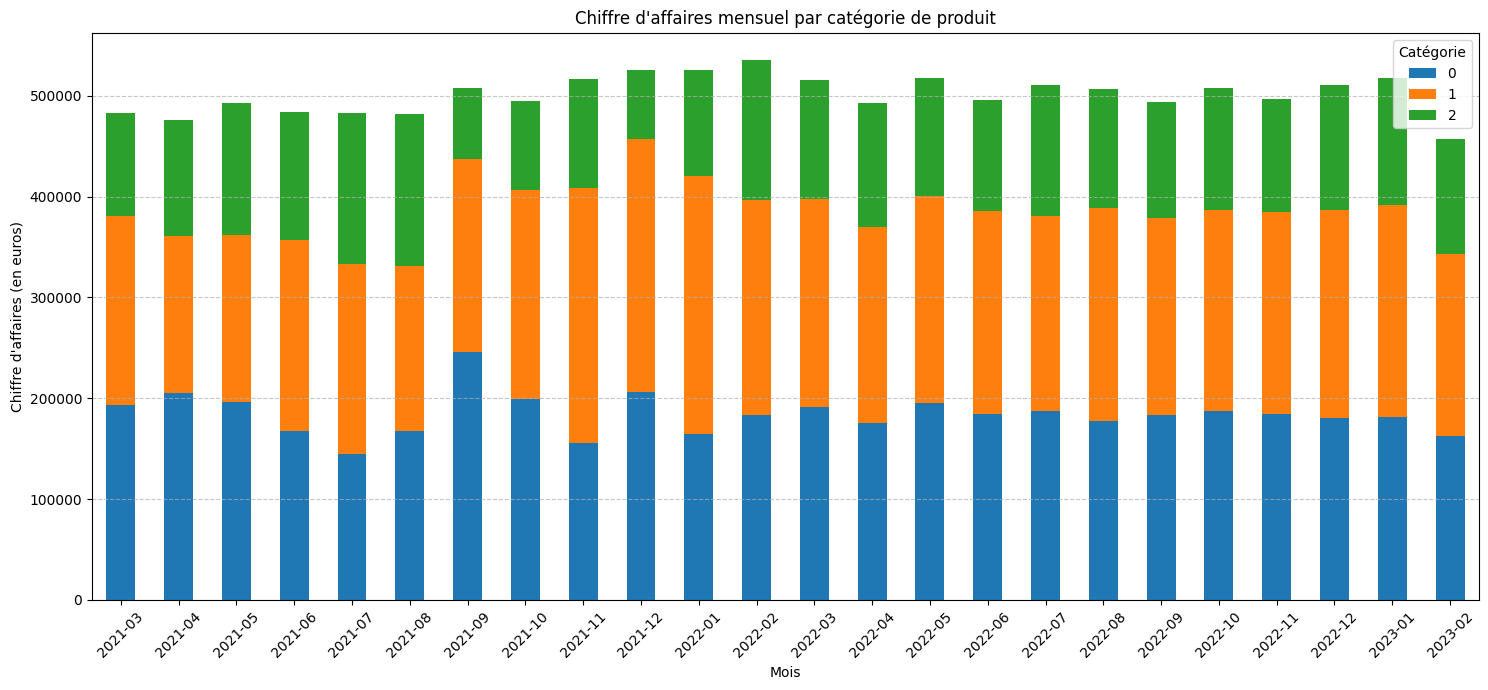

In [ ]:
# Calcul du chiffre d'affaires par mois et par catégorie
ca_par_mois_categorie = df_final.groupby([df_final['date'].dt.to_period('M'), 'categ'])['price'].sum().unstack().fillna(0)

# Convertir l'index Period à string pour l'affichage
ca_par_mois_categorie.index = ca_par_mois_categorie.index.astype(str)

# Visualisation en barres empilées
plt.figure(figsize=(15, 7))
ca_par_mois_categorie.plot(kind='bar', stacked=True, figsize=(15, 7))
plt.title("Chiffre d'affaires mensuel par catégorie de produit")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (en euros)")
plt.xticks(rotation=45)
plt.legend(title='Catégorie')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

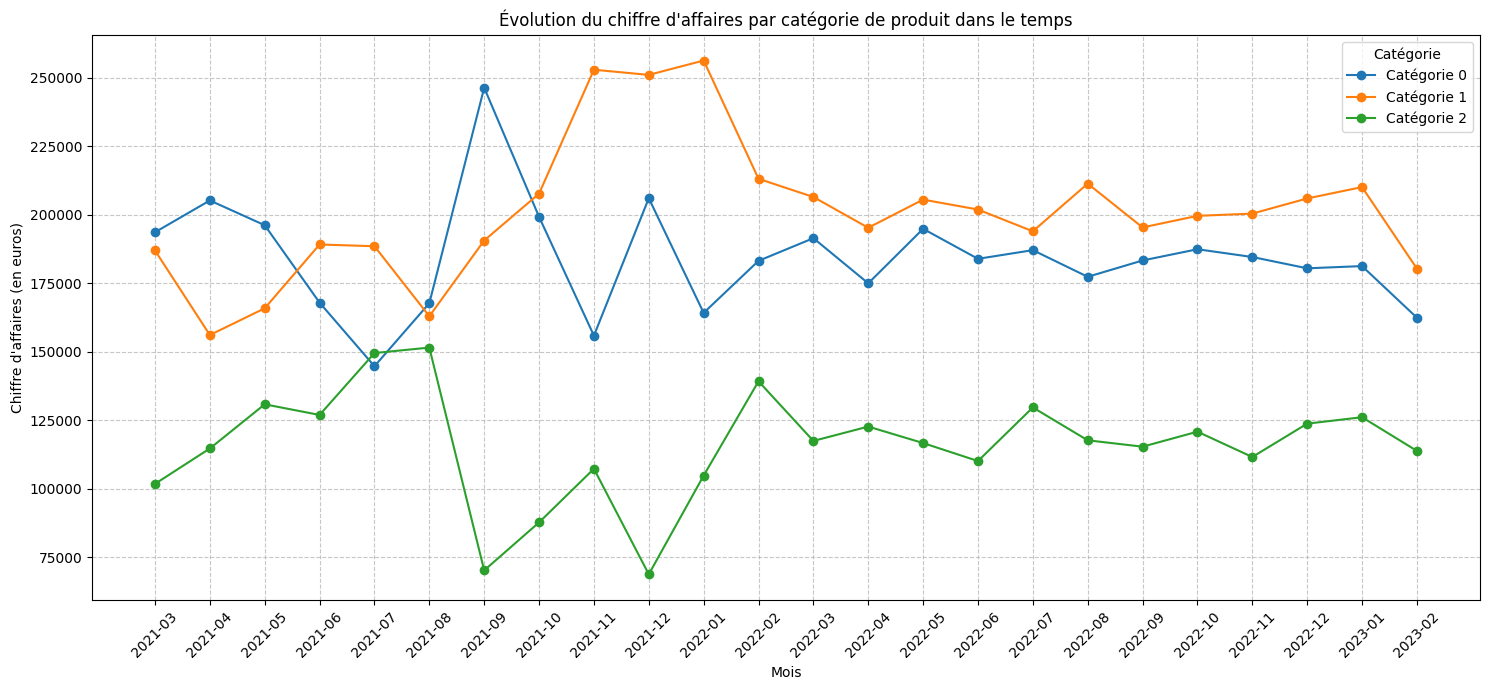

In [ ]:
# Visualisation de l'évolution du chiffre d'affaires des catégories dans le temps
plt.figure(figsize=(15, 7))

for column in ca_par_mois_categorie.columns:
    plt.plot(ca_par_mois_categorie.index, ca_par_mois_categorie[column], marker='o', label=f'Catégorie {column}')

plt.title("Évolution du chiffre d'affaires par catégorie de produit dans le temps")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (en euros)")
plt.xticks(rotation=45)
plt.legend(title='Catégorie')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

La catégorie 1 est le produit le plus populaire, suivi du 0 et 2, les CA sont assez stable depuis  mars 2022, il y a pourtant eu de gros écart en fin d'année 2021 pour les 3 produits. Il serait interessent de comprendre pourquoi.

In [ ]:
#Compter le nombre de référence par catégorie
references_par_categorie = products.groupby('categ')['id_prod'].count().reset_index()
references_par_categorie.columns = ['Catégorie', 'Nombre de références']
display(references_par_categorie)



,Catégorie,Nombre de références
0,0,2308
1,1,739
2,2,239


In [ ]:
# Grouper par id_prod et collecter les catégories uniques
produits_multicategories = products.groupby('id_prod')['categ'].nunique().reset_index()
produits_multicategories.columns = ['id_prod', 'nombre_de_categories']

# Filtrer pour trouver les produits dans plus d'une catégorie
produits_multicategories = produits_multicategories[produits_multicategories['nombre_de_categories'] > 1]

# Afficher les produits qui se trouvent dans plusieurs catégories
if not produits_multicategories.empty:
    print("Produits trouvés dans plusieurs catégories:")
    display(produits_multicategories)
else:
    print("Aucun produit trouvé dans plusieurs catégories.")

Aucun produit trouvé dans plusieurs catégories.


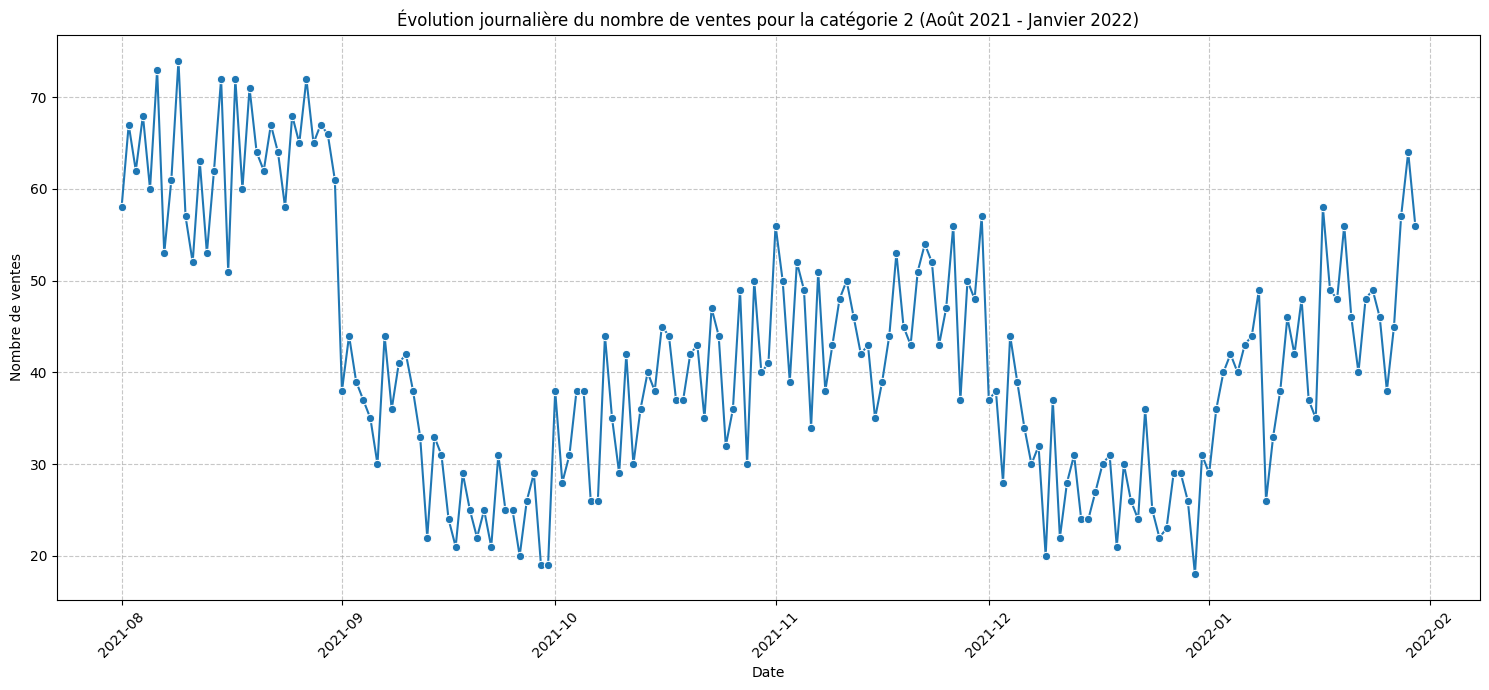

In [ ]:
vente_cat2 = df_final[(df_final['date'] >= '2021-08-01') & (df_final['date'] <= '2022-01-31') & (df_final['categ'] == 2)]
ventes_cat2_par_jour = vente_cat2.groupby(vente_cat2['date'].dt.date).size().reset_index(name='Nombre de ventes')
ventes_cat2_par_jour.rename(columns={'date': 'Date'}, inplace=True)

# Assurez-vous que la colonne 'Date' est au format datetime pour le tracé
ventes_cat2_par_jour['Date'] = pd.to_datetime(ventes_cat2_par_jour['Date'])

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Nombre de ventes', data=ventes_cat2_par_jour, marker='o')
plt.title('Évolution journalière du nombre de ventes pour la catégorie 2 (Août 2021 - Janvier 2022)')
plt.xlabel('Date')
plt.ylabel('Nombre de ventes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Nombre de client par mois


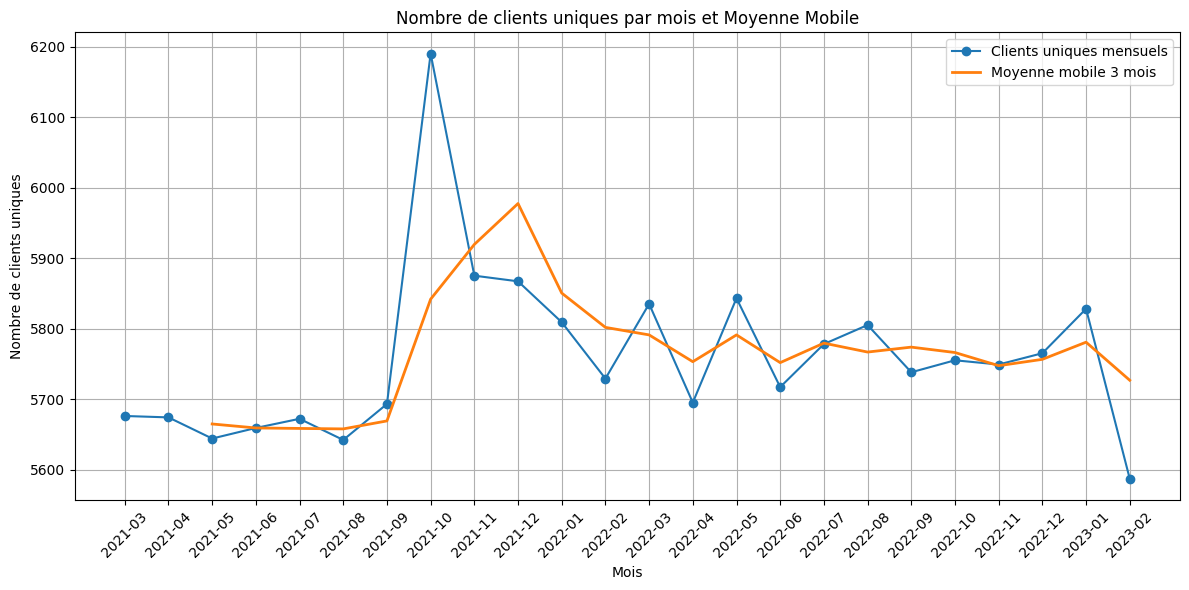

In [ ]:
# Calcul du nombre de clients uniques par mois
clients_par_mois = df_final.groupby(df_final['date'].dt.to_period('M'))['client_id'].nunique().reset_index()
clients_par_mois.columns = ['Mois', 'Nombre de clients uniques']
clients_par_mois['Mois'] = clients_par_mois['Mois'].astype(str)

# Calcul de la moyenne mobile sur 3 mois
clients_par_mois['MA_3'] = clients_par_mois['Nombre de clients uniques'].rolling(window=3).mean()

# Visualisation du nombre de clients uniques par mois et de la moyenne mobile
plt.figure(figsize=(12, 6))
plt.plot(clients_par_mois['Mois'], clients_par_mois['Nombre de clients uniques'], label='Clients uniques mensuels', marker='o')
plt.plot(clients_par_mois['Mois'], clients_par_mois['MA_3'], label='Moyenne mobile 3 mois', linewidth=2)


plt.title('Nombre de clients uniques par mois et Moyenne Mobile')
plt.xlabel('Mois')
plt.xticks(rotation=45)
plt.ylabel('Nombre de clients uniques')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
moyenne_clients_par_mois = clients_par_mois['Nombre de clients uniques'].mean()
print(f"En moyenne, il y a {moyenne_clients_par_mois:.2f} clients uniques par mois.")

En moyenne, il y a 5759.38 clients uniques par mois.


On constate une diminution et une stabilisation du nombre de client après un pique en fin 2021

### Nombre de transactions par mois

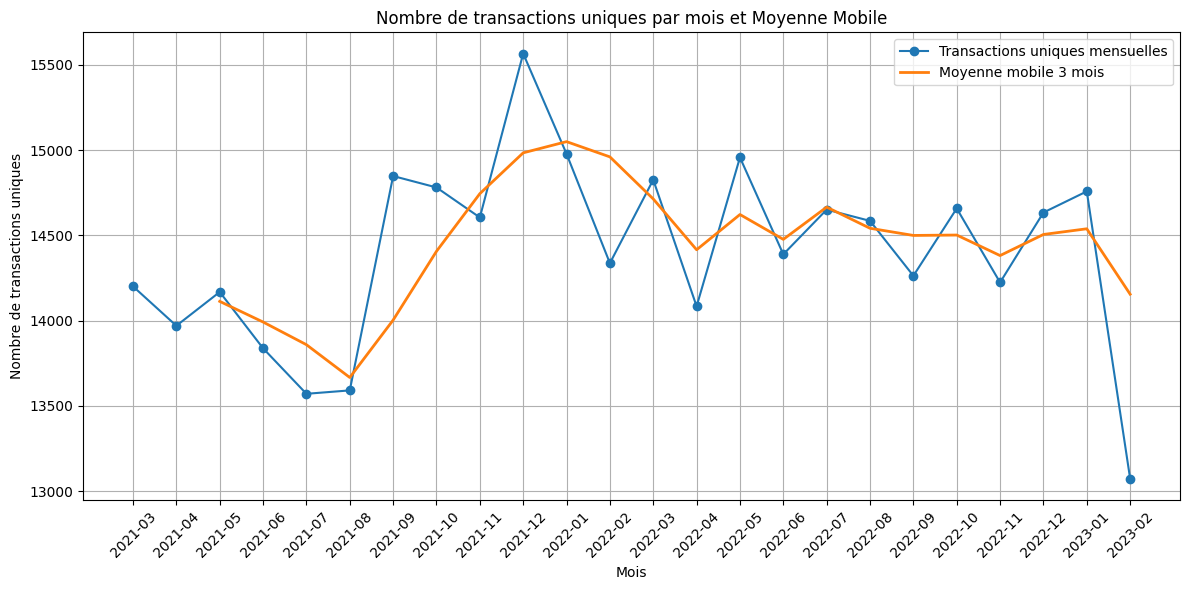

In [ ]:
# Calcul du nombre de transactions uniques par mois
transactions_par_mois = df_final.groupby(df_final['date'].dt.to_period('M'))['session_id'].nunique().reset_index()
transactions_par_mois.columns = ['Mois', 'Nombre de transactions uniques']
transactions_par_mois['Mois'] = transactions_par_mois['Mois'].astype(str)

# Calcul de la moyenne mobile sur 3 mois
transactions_par_mois['MA_3'] = transactions_par_mois['Nombre de transactions uniques'].rolling(window=3).mean()

# Visualisation du nombre de transactions uniques par mois et de la moyenne mobile
plt.figure(figsize=(12, 6))
plt.plot(transactions_par_mois['Mois'], transactions_par_mois['Nombre de transactions uniques'], label='Transactions uniques mensuelles', marker='o')
plt.plot(transactions_par_mois['Mois'], transactions_par_mois['MA_3'], label='Moyenne mobile 3 mois', linewidth=2)
plt.title('Nombre de transactions uniques par mois et Moyenne Mobile')
plt.xlabel('Mois')
plt.xticks(rotation=45)
plt.ylabel('Nombre de transactions uniques')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Nombre de produits vendu

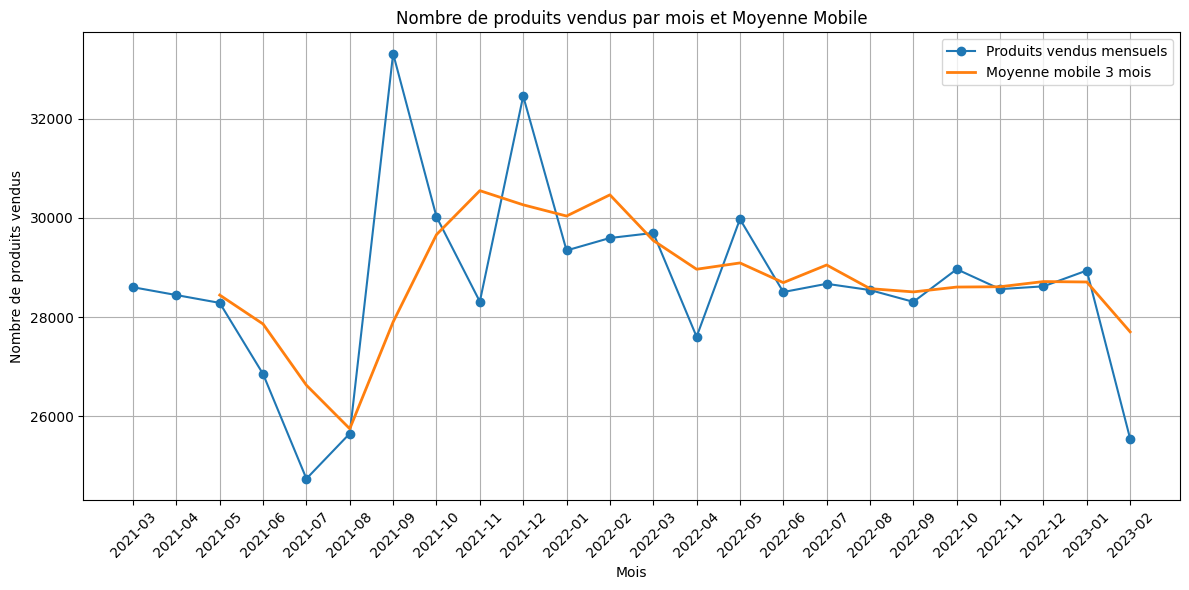

In [ ]:
# Calcul du nombre de produits vendus par mois
produits_vendus_par_mois = df_final.groupby(df_final['date'].dt.to_period('M')).size().reset_index(name='Nombre de produits vendus')
produits_vendus_par_mois.rename(columns={'date': 'Mois'}, inplace=True)
produits_vendus_par_mois['Mois'] = produits_vendus_par_mois['Mois'].astype(str)

# Calcul de la moyenne mobile sur 3 mois
produits_vendus_par_mois['MA_3'] = produits_vendus_par_mois['Nombre de produits vendus'].rolling(window=3).mean()

# Visualisation du nombre de produits vendus par mois et de la moyenne mobile
plt.figure(figsize=(12, 6))
plt.plot(produits_vendus_par_mois['Mois'], produits_vendus_par_mois['Nombre de produits vendus'], label='Produits vendus mensuels', marker='o')
plt.plot(produits_vendus_par_mois['Mois'], produits_vendus_par_mois['MA_3'], label='Moyenne mobile 3 mois', linewidth=2)
plt.title('Nombre de produits vendus par mois et Moyenne Mobile')
plt.xlabel('Mois')
plt.xticks(rotation=45)
plt.ylabel('Nombre de produits vendus')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Pour aller plus loin dans l'études des catégories, voyons la répartition selon le CA et la quantité vendu

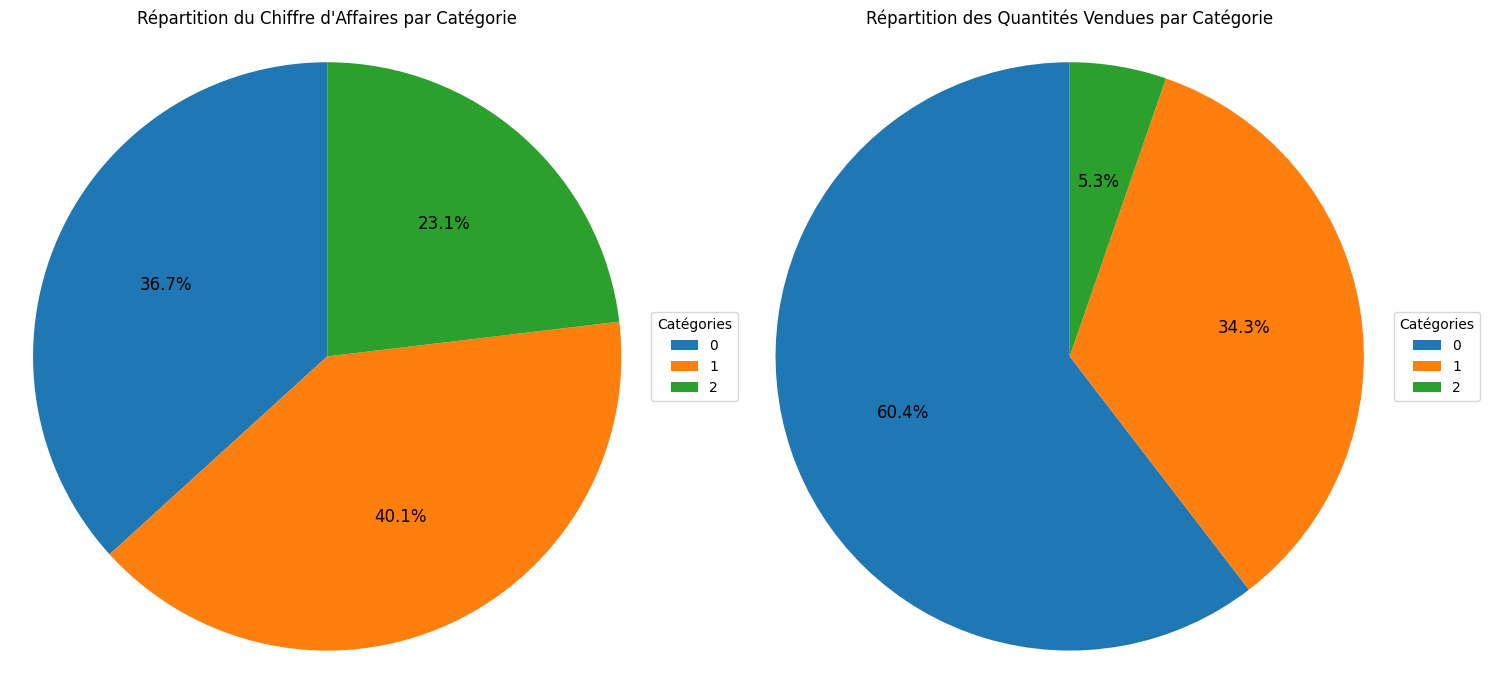

In [ ]:
# Calcul du chiffre d'affaires par catégorie (déjà calculé, mais je l'affiche pour référence)
ca_par_categorie = df_final.groupby('categ')['price'].sum().reset_index()
ca_par_categorie.columns = ['Catégorie', 'Chiffre d affaire']

# Calcul de la quantité vendue par catégorie
quantite_par_categorie = df_final.groupby('categ').size().reset_index(name='Quantité vendue')
quantite_par_categorie.columns = ['Catégorie', 'Quantité vendue']

# Visualisation du chiffre d'affaires par catégorie (Camembert)
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1) # 1 ligne, 2 colonnes, 1er graphique
wedges_ca, texts_ca, autotexts_ca = plt.pie(ca_par_categorie['Chiffre d affaire'], autopct='%1.1f%%', startangle=90)
plt.title("Répartition du Chiffre d'Affaires par Catégorie")
plt.axis('equal') # Assure que le camembert est un cercle.
plt.legend(wedges_ca, ca_par_categorie['Catégorie'], title="Catégories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
for autotext in autotexts_ca:
    autotext.set_fontsize(12) # Augmenter la taille de la police des pourcentages

# Visualisation de la quantité vendue par catégorie (Camembert)
plt.subplot(1, 2, 2) # 1 ligne, 2 colonnes, 2ème graphique
wedges_qte, texts_qte, autotexts_qte = plt.pie(quantite_par_categorie['Quantité vendue'], autopct='%1.1f%%', startangle=90)
plt.title('Répartition des Quantités Vendues par Catégorie')
plt.axis('equal') # Assure que le camembert est un cercle.
plt.legend(wedges_qte, quantite_par_categorie['Catégorie'], title="Catégories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
for autotext in autotexts_qte:
    autotext.set_fontsize(12) # Augmenter la taille de la police des pourcentages

plt.tight_layout()
plt.show()

Ce graphique permet de réaliser une chose importante, si les catégories 0 et 1 ont un CA relativement similaire, la quantité de produits vendus est elle plus inégale. Il y a peut-etre des prix très différents dans les catégories, on va tracer une distribution des prix.

## Analyse des références

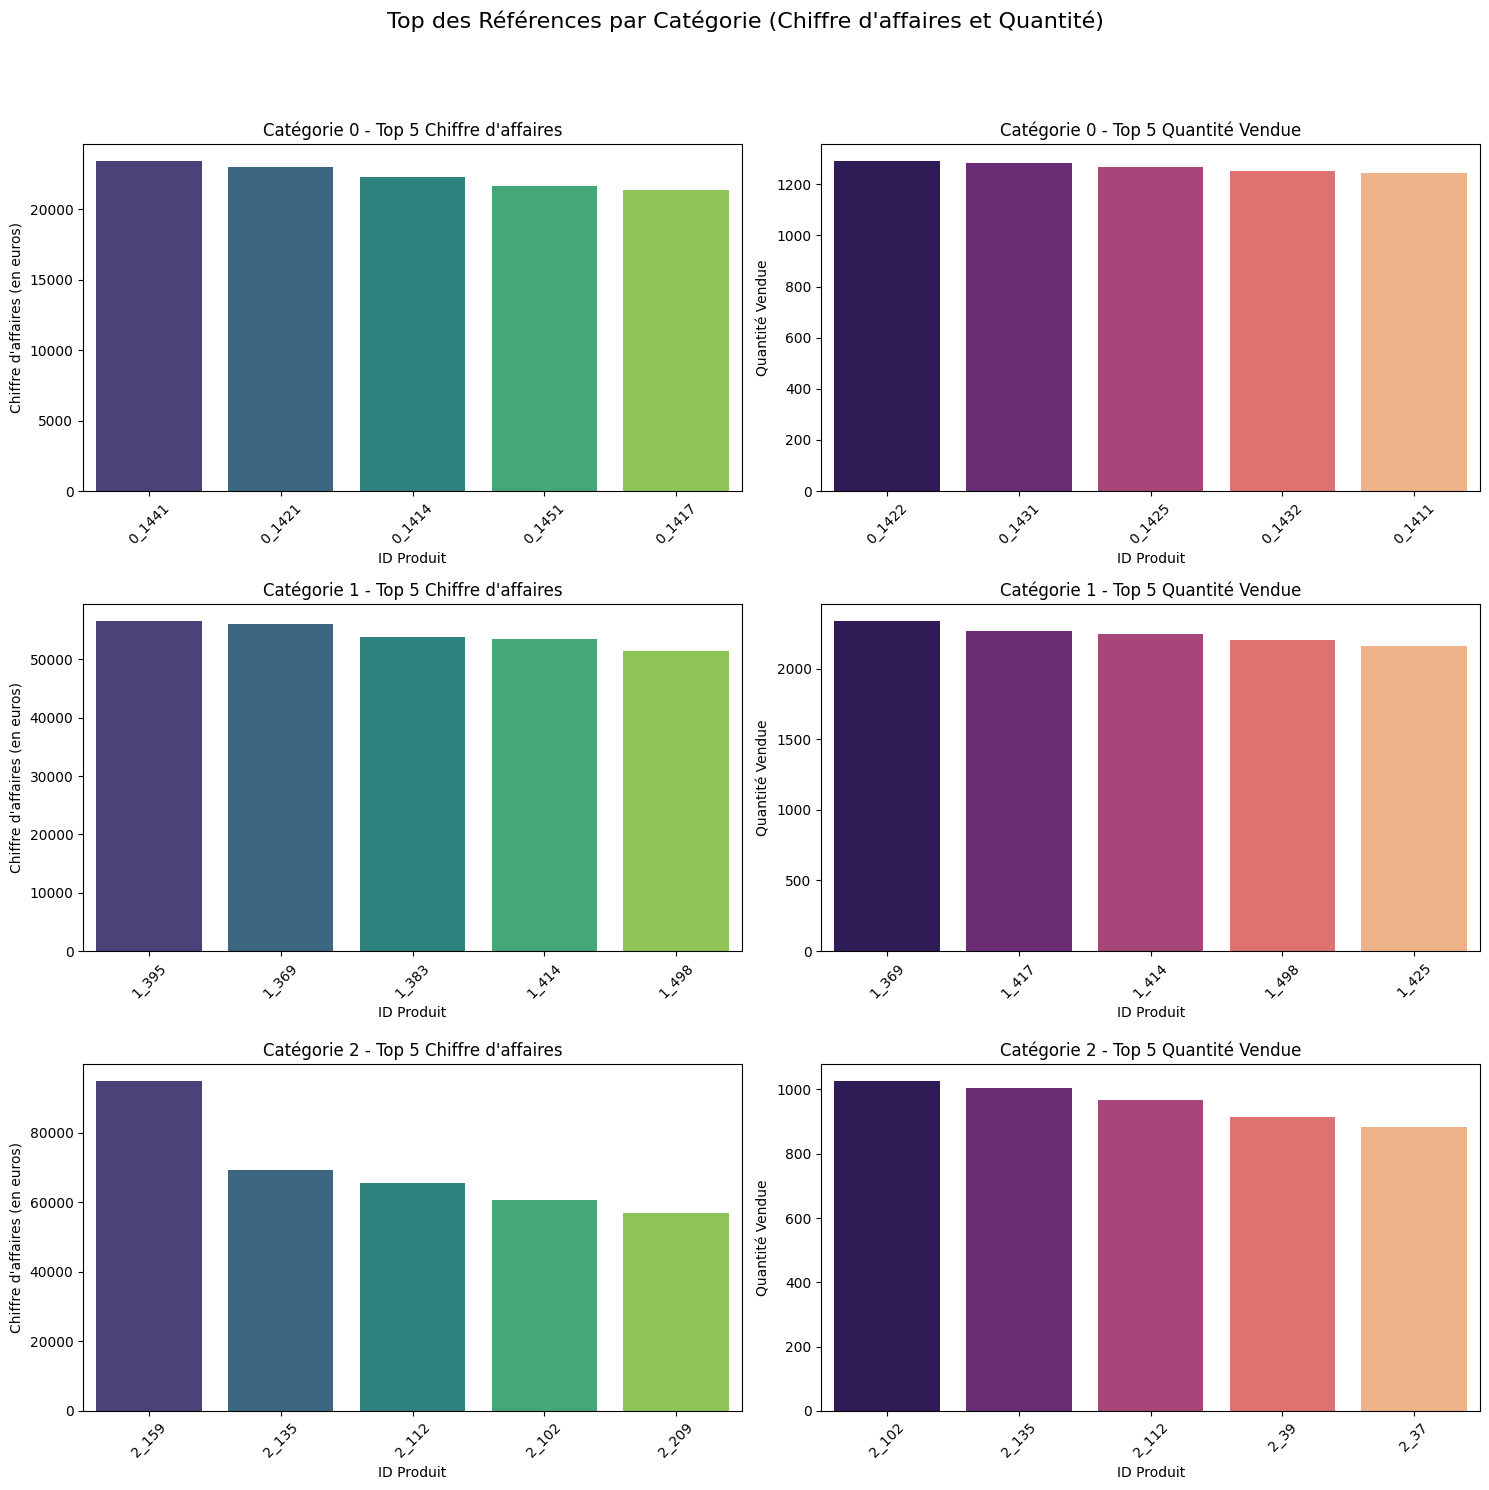

In [ ]:

def get_top_products(df, category_id, metric='price', top_n=5):

    df_cat = df[df['categ'] == category_id]
    if metric == 'price':
        top_products = df_cat.groupby('id_prod')['price'].sum().nlargest(top_n)
    else:
        top_products = df_cat['id_prod'].value_counts().nlargest(top_n)
    return top_products


categories = df_final['categ'].unique()
categories.sort()

fig, axes = plt.subplots(nrows=len(categories), ncols=2, figsize=(15, 5 * len(categories)))
fig.suptitle("Top des Références par Catégorie (Chiffre d'affaires et Quantité)", y=1.02, fontsize=16)

for i, categ in enumerate(categories):
    # Top par Chiffre d'Affaire
    top_ca = get_top_products(df_final, categ, metric='price')
    sns.barplot(x=top_ca.index, y=top_ca.values, ax=axes[i, 0], palette='viridis', hue=top_ca.index, legend=False)
    axes[i, 0].set_title(f"Catégorie {categ} - Top {5} Chiffre d'affaires")
    axes[i, 0].set_xlabel("ID Produit")
    axes[i, 0].set_ylabel("Chiffre d'affaires (en euros)")
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Top par Quantité
    top_qty = get_top_products(df_final, categ, metric='count')
    sns.barplot(x=top_qty.index, y=top_qty.values, ax=axes[i, 1], palette='magma', hue=top_qty.index, legend=False)
    axes[i, 1].set_title(f"Catégorie {categ} - Top {5} Quantité Vendue")
    axes[i, 1].set_xlabel("ID Produit")
    axes[i, 1].set_ylabel("Quantité Vendue")
    axes[i, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

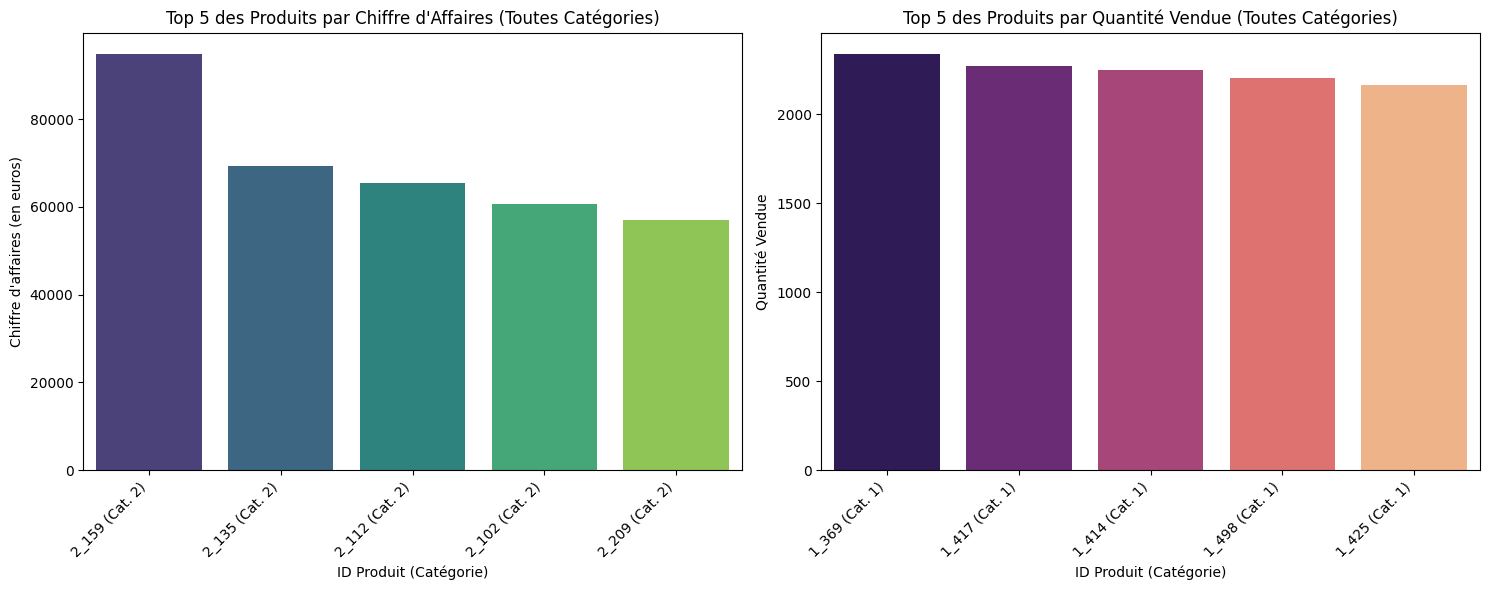

In [ ]:
# Calcul du chiffre d'affaires par produit (toutes catégories confondues)
ca_par_produit_df = df_final.groupby('id_prod')['price'].sum().nlargest(5).reset_index()
ca_par_produit_df.columns = ['id_prod', 'Chiffre d affaire']
ca_par_produit_df = pd.merge(ca_par_produit_df, products[['id_prod', 'categ']], on='id_prod', how='left')
ca_par_produit_df['label'] = ca_par_produit_df['id_prod'] + ' (Cat. ' + ca_par_produit_df['categ'].astype(str) + ')'

# Calcul de la quantité vendue par produit (toutes catégories confondues)
quantite_par_produit_df = df_final['id_prod'].value_counts().nlargest(5).reset_index()
quantite_par_produit_df.columns = ['id_prod', 'Quantité Vendue']
quantite_par_produit_df = pd.merge(quantite_par_produit_df, products[['id_prod', 'categ']], on='id_prod', how='left')
quantite_par_produit_df['label'] = quantite_par_produit_df['id_prod'] + ' (Cat. ' + quantite_par_produit_df['categ'].astype(str) + ')'

plt.figure(figsize=(15, 6))

# Histogramme pour le top 5 des produits par CA
plt.subplot(1, 2, 1)
sns.barplot(x=ca_par_produit_df['label'], y=ca_par_produit_df['Chiffre d affaire'], palette='viridis', hue=ca_par_produit_df['label'], legend=False)
plt.title("Top 5 des Produits par Chiffre d'Affaires (Toutes Catégories)")
plt.xlabel("ID Produit (Catégorie)")
plt.ylabel("Chiffre d'affaires (en euros)")
plt.xticks(rotation=45, ha='right')

# Histogramme pour le top 5 des produits par Quantité Vendue
plt.subplot(1, 2, 2)
sns.barplot(x=quantite_par_produit_df['label'], y=quantite_par_produit_df['Quantité Vendue'], palette='magma', hue=quantite_par_produit_df['label'], legend=False)
plt.title("Top 5 des Produits par Quantité Vendue (Toutes Catégories)")
plt.xlabel("ID Produit (Catégorie)")
plt.ylabel("Quantité Vendue")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

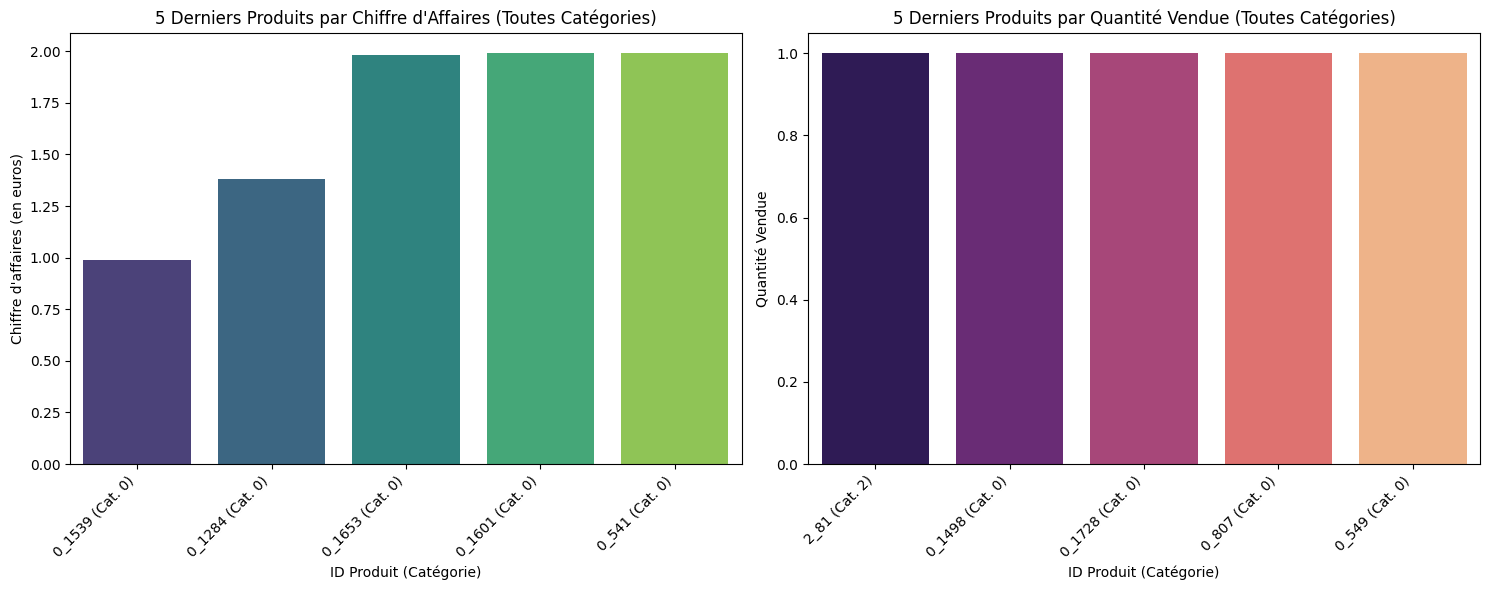

In [ ]:
# Calcul du chiffre d'affaires par produit (toutes catégories confondues) pour les 5 derniers
ca_par_produit_df_last5 = df_final.groupby('id_prod')['price'].sum().nsmallest(5).reset_index()
ca_par_produit_df_last5.columns = ['id_prod', 'Chiffre d affaire']
ca_par_produit_df_last5 = pd.merge(ca_par_produit_df_last5, products[['id_prod', 'categ']], on='id_prod', how='left')
ca_par_produit_df_last5['label'] = ca_par_produit_df_last5['id_prod'] + ' (Cat. ' + ca_par_produit_df_last5['categ'].astype(str) + ')'

# Calcul de la quantité vendue par produit (toutes catégories confondues) pour les 5 derniers
quantite_par_produit_df_last5 = df_final['id_prod'].value_counts().nsmallest(5).reset_index()
quantite_par_produit_df_last5.columns = ['id_prod', 'Quantité Vendue']
quantite_par_produit_df_last5 = pd.merge(quantite_par_produit_df_last5, products[['id_prod', 'categ']], on='id_prod', how='left')
quantite_par_produit_df_last5['label'] = quantite_par_produit_df_last5['id_prod'] + ' (Cat. ' + quantite_par_produit_df_last5['categ'].astype(str) + ')'

plt.figure(figsize=(15, 6))

# Histogramme pour les 5 derniers produits par CA
plt.subplot(1, 2, 1)
sns.barplot(x=ca_par_produit_df_last5['label'], y=ca_par_produit_df_last5['Chiffre d affaire'], palette='viridis', hue=ca_par_produit_df_last5['label'], legend=False)
plt.title("5 Derniers Produits par Chiffre d'Affaires (Toutes Catégories)")
plt.xlabel("ID Produit (Catégorie)")
plt.ylabel("Chiffre d'affaires (en euros)")
plt.xticks(rotation=45, ha='right')

# Histogramme pour les 5 derniers produits par Quantité Vendue
plt.subplot(1, 2, 2)
sns.barplot(x=quantite_par_produit_df_last5['label'], y=quantite_par_produit_df_last5['Quantité Vendue'], palette='magma', hue=quantite_par_produit_df_last5['label'], legend=False)
plt.title("5 Derniers Produits par Quantité Vendue (Toutes Catégories)")
plt.xlabel("ID Produit (Catégorie)")
plt.ylabel("Quantité Vendue")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

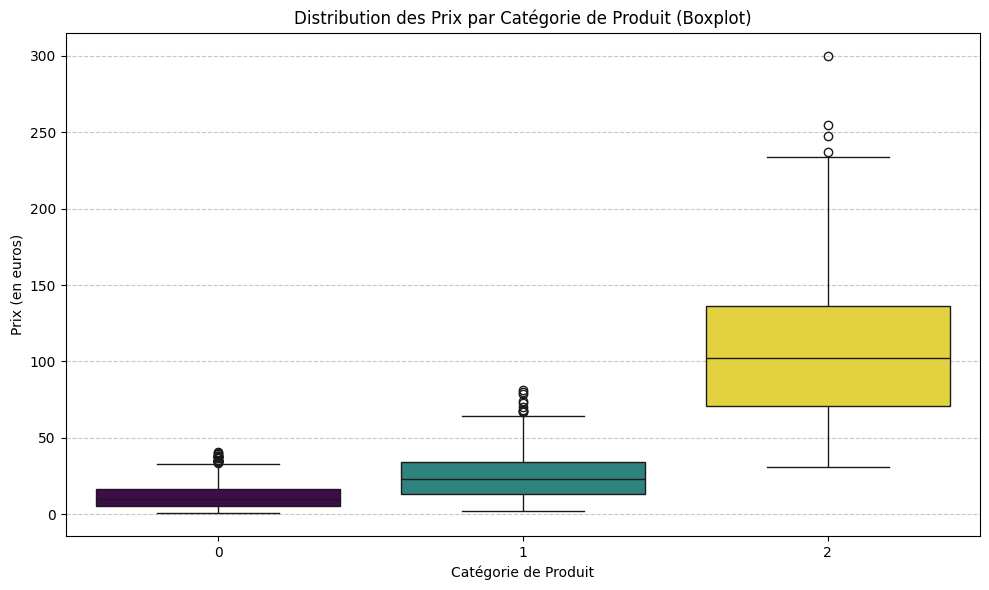

In [ ]:
#Distributuin des prix par catégories
plt.figure(figsize=(10, 6))
sns.boxplot(x='categ', y='price', data=products, palette='viridis', hue='categ', legend=False)
plt.title('Distribution des Prix par Catégorie de Produit (Boxplot)')
plt.xlabel('Catégorie de Produit')
plt.ylabel('Prix (en euros)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

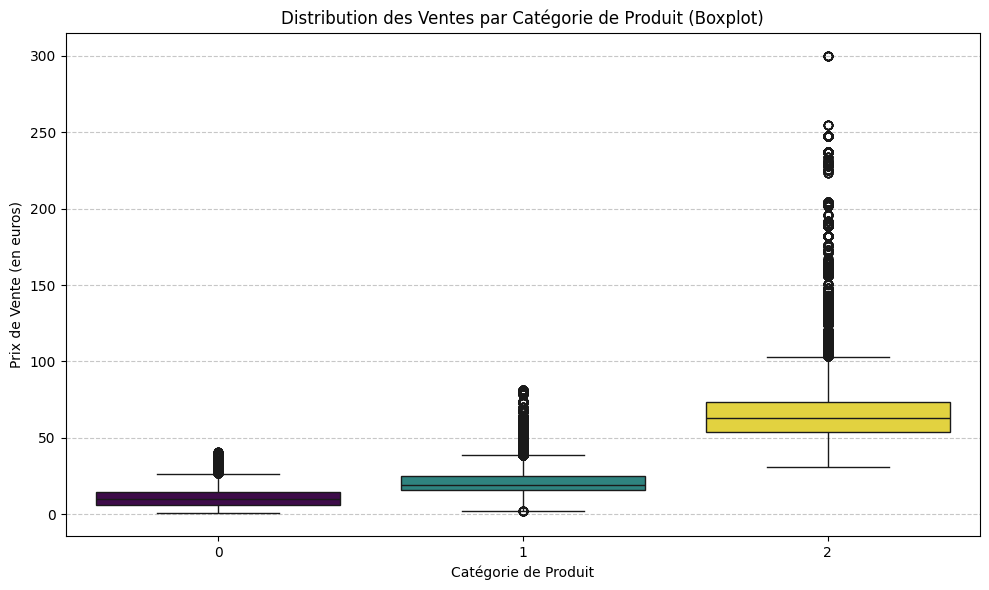

In [ ]:
#Distribution des ventes par catégories

plt.figure(figsize=(10, 6))
sns.boxplot(x='categ', y='price', data=df_final, palette='viridis', hue='categ', legend=False)
plt.title('Distribution des Ventes par Catégorie de Produit (Boxplot)')
plt.xlabel('Catégorie de Produit')
plt.ylabel('Prix de Vente (en euros)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Voyons disparité des ventes par catégorie

In [ ]:
# Calcul du CA par catégories
ca_par_categorie_disparity = df_final.groupby('categ')['price'].sum().reset_index()
ca_par_categorie_disparity.columns = ['Catégorie', 'Chiffre d affaire']

# Calcul du total de vente par catégories
quantite_par_categorie_disparity = df_final.groupby('categ').size().reset_index(name='Quantité vendue')
quantite_par_categorie_disparity.columns = ['Catégorie', 'Quantité vendue']

# comparaison
disparity_df = pd.merge(ca_par_categorie_disparity, quantite_par_categorie_disparity, on='Catégorie')

print("Disparité des ventes par catégorie:")
display(disparity_df)

Disparité des ventes par catégorie:


,Catégorie,Chiffre d affaire,Quantité vendue
0,0,4419730.97,415459
1,1,4827657.11,235592
2,2,2780275.02,36483


In [ ]:
#Voyons le nombre de ptoduit par catégorie
nombre_produits_par_categorie = products.groupby('categ')['id_prod'].nunique().reset_index()
nombre_produits_par_categorie.columns = ['Catégorie', 'Nombre de produits uniques']
display(nombre_produits_par_categorie)

,Catégorie,Nombre de produits uniques
0,0,2308
1,1,739
2,2,239


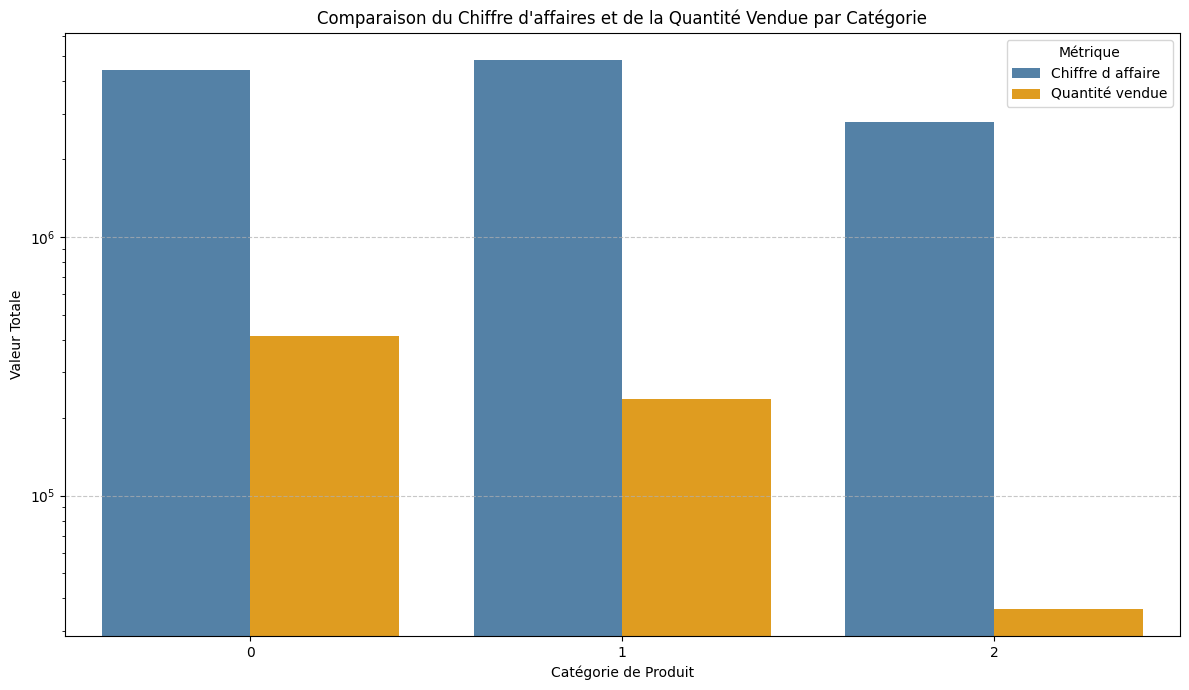

In [ ]:
# Si on compare les deux variables
disparity_melted = disparity_df.melt(id_vars='Catégorie', var_name='Métrique', value_name='Valeur')

plt.figure(figsize=(12, 7))
sns.barplot(x='Catégorie', y='Valeur', hue='Métrique', data=disparity_melted, palette={'Chiffre d affaire': 'steelblue', 'Quantité vendue': 'orange'})
plt.title('Comparaison du Chiffre d\'affaires et de la Quantité Vendue par Catégorie')
plt.xlabel('Catégorie de Produit')
plt.ylabel('Valeur Totale')
plt.yscale('log')
plt.legend(title='Métrique')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Analyse sur les clients

In [ ]:
#Classement des clients par chiffre d'affaire
clients_par_ca = df_final.groupby('client_id')['price'].sum().reset_index()
clients_par_ca = clients_par_ca.sort_values(by='price', ascending=False)

#Affichage du top 10 des clients
top_10_clients = clients_par_ca.head(10)
print(top_10_clients)

     client_id      price
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57
634     c_1570    5285.82
2513    c_3263    5276.87
1268    c_2140    5260.18
2108    c_2899    5214.05
7006    c_7319    5155.77
7715    c_7959    5135.75


On constate que 4 clients sortent du lot, au vu des montants, nous pouvons légitimement pensée qu'il s'agit de client professionnel

In [ ]:
#Affichage des catégories d'achats pour les 4 premier clients
clients_cat = df_final[df_final['client_id'].isin(top_10_clients['client_id'])]
clients_cat = clients_cat.groupby(['client_id', 'categ']).size().reset_index()
clients_cat.columns = ['client_id', 'category', 'count']
display(clients_cat)

,client_id,category,count
0,c_1570,0,260
1,c_1570,1,109
2,c_1570,2,1
3,c_1609,0,20167
4,c_1609,1,5408
5,c_1609,2,11
6,c_2140,0,310
7,c_2140,1,94
8,c_2140,2,1
9,c_2899,0,3


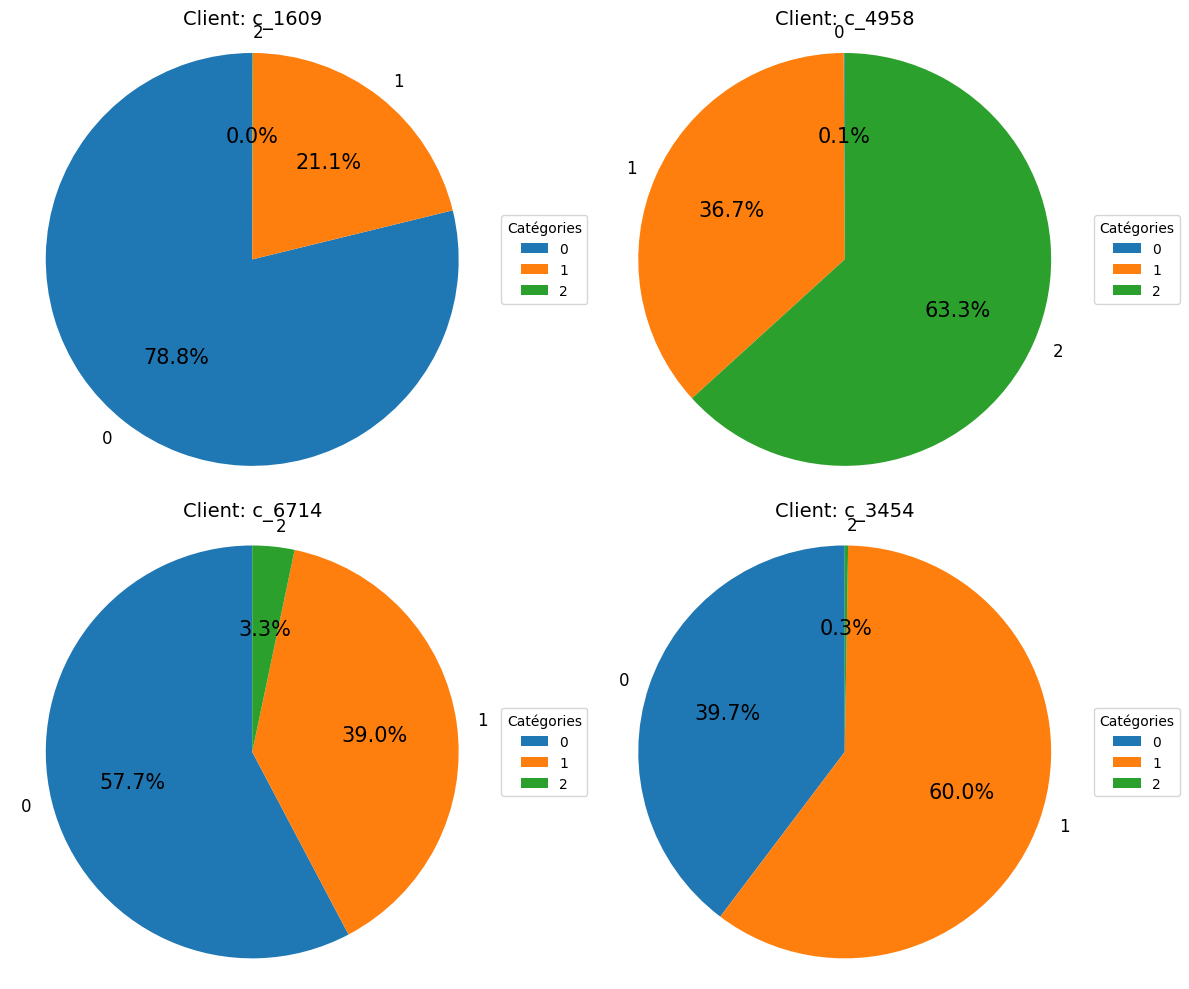

In [ ]:
#Répartition des catégories pour les 4 clients entreprises

# Avoir les 4 clients entreprises
top_4_client_ids = clients_par_ca.head(4)['client_id'].tolist()

# Filtrer sur ces 4 clients
clients_cat_top4 = clients_cat[clients_cat['client_id'].isin(top_4_client_ids)]

# Création du graphique
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, client_id in enumerate(top_4_client_ids):
    client_data = clients_cat_top4[clients_cat_top4['client_id'] == client_id]


    if not client_data.empty:
        ax = axes[i]
        wedges, texts, autotexts = ax.pie(client_data['count'], labels=client_data['category'], autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
        ax.set_title(f'Client: {client_id}', fontsize=14)
        ax.axis('equal')
        ax.legend(wedges, client_data['category'], title='Catégories', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))

        for autotext in autotexts:
            autotext.set_fontsize(15)
    else:

        axes[i].set_title(f'Client: {client_id} - No Data')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

Je vais maintenant créer un DF qui ne comporte pas ces 4 clients entreprises


In [ ]:
# Création d'un DF sans les 4 clients entreprises
df_final_individual = df_final[~df_final['client_id'].isin(top_4_client_ids)]
df_clean = df_final_individual.copy()

display(df_clean.head())
print(f"Les dimensions du DataFrame df_clean sont : {df_clean.shape}")

,id_prod,date,session_id,client_id,price,categ,sex,birth,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,56
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,63
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,35
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,34
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,67


Les dimensions du DataFrame df_clean sont : (640734, 9)


Comme mentionné précédemment, `df_clean` a été créé à partir de `df_final_individual`, qui est le DataFrame `df_final` sans les transactions des 4 clients entreprises identifiés. Pour le confirmer, nous pouvons vérifier si les `client_id` des 4 entreprises sont présents dans `df_clean`.

In [ ]:
# Vérifier si les IDs des clients entreprises sont présents dans df_clean
enterprise_clients_in_df_clean = df_clean[df_clean['client_id'].isin(top_4_client_ids)]

if enterprise_clients_in_df_clean.empty:
    print("Aucune transaction des 4 clients entreprises n'est présente dans df_clean.")
else:
    print("Des transactions des clients entreprises ont été trouvées dans df_clean (ce qui est inattendu).")
    display(enterprise_clients_in_df_clean.head())

Aucune transaction des 4 clients entreprises n'est présente dans df_clean.


Enregistrer et exporter ce nouveau DataFram pour l'utiliser dans un nouveau *Notebook*



In [ ]:
# Chemin où vous souhaitez sauvegarder le fichier dans votre Google Drive
#output_path = '/content/drive/MyDrive/Projet_9_Data/df_clean.csv'

# Sauvegarder le DataFrame en CSV
#df_clean.to_csv(output_path, index=False)

#print(f"Le DataFrame 'df_clean' a été sauvegardé avec succès dans : {output_path}")

### Analyses des clients particuliers

Voyons la répartition des clients par tranches d'age

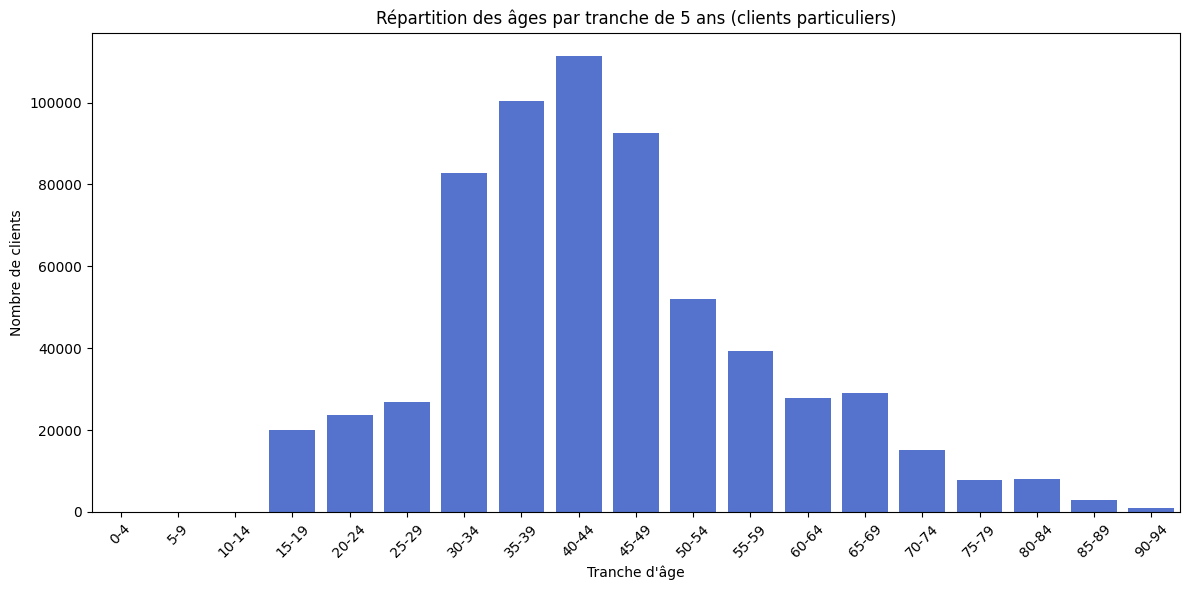

In [ ]:
# Création des tranches d'âge de 5 ans pour les clients du df_clean
bins_clean = range(0, df_clean['age'].max() + 5, 5)
labels_clean = [f"{start}-{start+4}" for start in bins_clean[:-1]]
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins_clean, labels=labels_clean, right=True)

# Compter les clients par tranches d'âge dans df_clean
clients_par_age_clean = df_clean['age_group'].value_counts().reset_index()
clients_par_age_clean.columns = ['age_group', 'count'] # S'assurer de noms de colonnes cohérents

# Trier par tranche d'âge croissante
clients_par_age_clean['age_group'] = pd.Categorical(clients_par_age_clean['age_group'], categories=labels_clean, ordered=True)
clients_par_age_clean = clients_par_age_clean.sort_values('age_group')

# Graphique de la répartition des clients par tranche d'âge de 5 ans (df_clean)
plt.figure(figsize=(12,6))
sns.barplot(x='age_group', y='count', data=clients_par_age_clean, color='royalblue') # Modifié pour une couleur unie
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre de clients")
plt.title("Répartition des âges par tranche de 5 ans (clients particuliers)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Il serait également interessent de voir la répartition par sexe

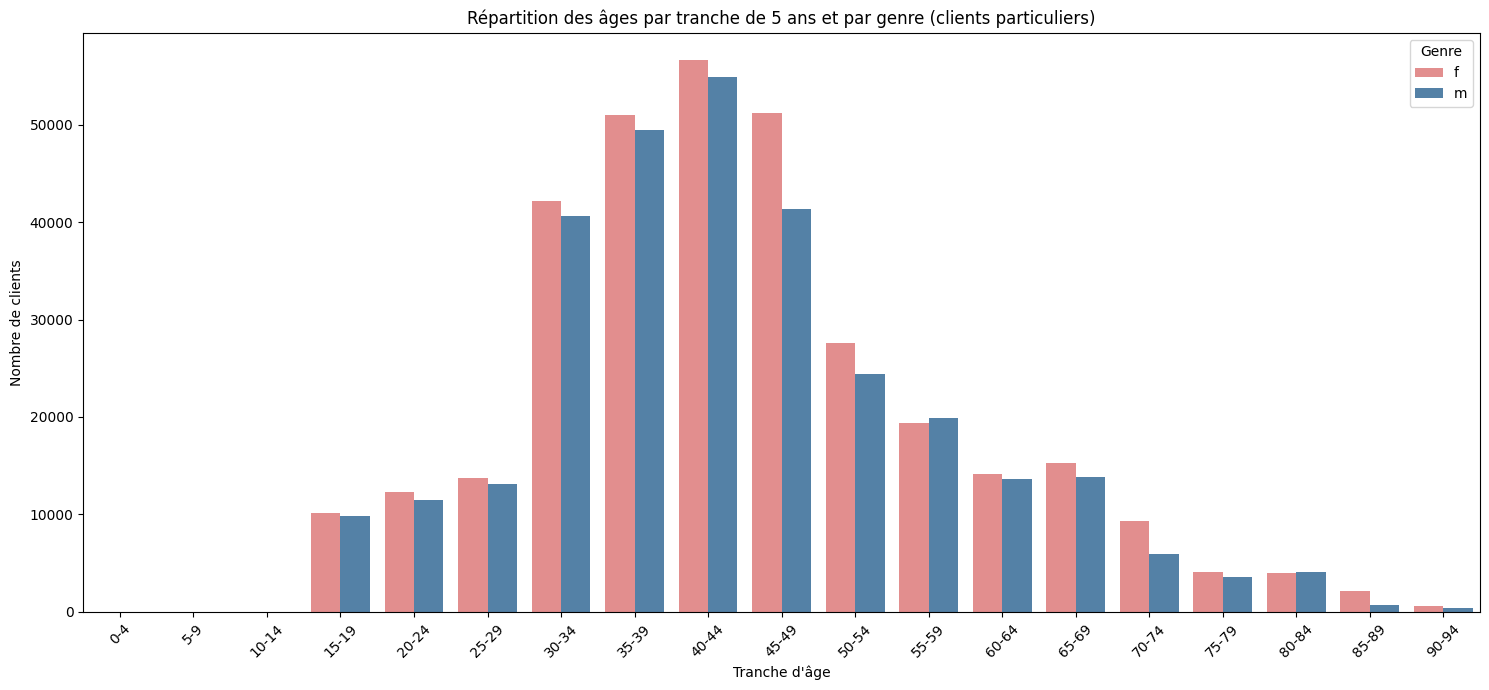

In [ ]:

# Compter les clients par tranches d'âge et par genre dans df_clean
clients_par_age_sexe_clean = df_clean.groupby(['age_group', 'sex'], observed=False).size().reset_index(name='count')

bins_clean = range(0, df_clean['age'].max() + 5, 5)
labels_clean = [f"{start}-{start+4}" for start in bins_clean[:-1]]
clients_par_age_sexe_clean['age_group'] = pd.Categorical(clients_par_age_sexe_clean['age_group'], categories=labels_clean, ordered=True)
clients_par_age_sexe_clean = clients_par_age_sexe_clean.sort_values('age_group')

# Graphique de la répartition des clients par tranche d'âge de 5 ans et par genre
plt.figure(figsize=(15, 7))
sns.barplot(x='age_group', y='count', hue='sex', data=clients_par_age_sexe_clean, palette={'f': 'lightcoral', 'm': 'steelblue'})
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre de clients")
plt.title("Répartition des âges par tranche de 5 ans et par genre (clients particuliers)")
plt.xticks(rotation=45)
plt.legend(title='Genre')
plt.tight_layout()
plt.show()

In [ ]:
#Voyons quelques statistique sur le genre
sex_stats = df_clean.drop_duplicates(subset=['client_id'], keep='first')[
    ['sex', 'age']]

display(sex_stats.groupby(['sex'])['age'].describe().T)

sex,f,m
count,4478.000000,4118.000000
mean,45.025011,44.429335
std,17.092603,16.706855
min,19.000000,19.000000
25%,31.000000,31.000000
50%,44.000000,43.000000
75%,57.000000,57.000000
max,94.000000,94.000000


### Courbe de Lorenz

La courbe de Lorenz nous sert à visualiser le niveau d'inégalité du CA par client

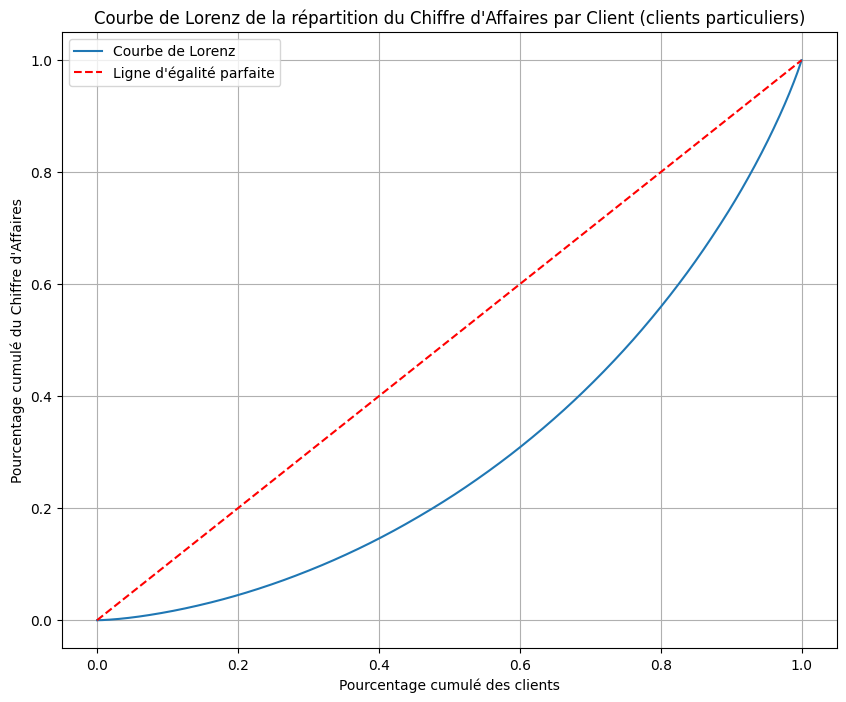

In [ ]:
# Calcul du total des achats par clients
ca_par_client_clean = df_clean.groupby('client_id')['price'].sum().sort_values().reset_index()

# Pourcentage cumulées pour les clients et les ventes
ca_par_client_clean['cum_clients'] = np.arange(1, len(ca_par_client_clean) + 1) / len(ca_par_client_clean)
ca_par_client_clean['cum_ca'] = ca_par_client_clean['price'].cumsum() / ca_par_client_clean['price'].sum()

# Graphique de la courbe de Lorenz
plt.figure(figsize=(10, 8))
plt.plot(ca_par_client_clean['cum_clients'], ca_par_client_clean['cum_ca'], label='Courbe de Lorenz')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Ligne d\'égalité parfaite')
plt.title('Courbe de Lorenz de la répartition du Chiffre d\'Affaires par Client (clients particuliers)')
plt.xlabel('Pourcentage cumulé des clients')
plt.ylabel('Pourcentage cumulé du Chiffre d\'Affaires')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Calcul du coefficient de Gini
# x-axis pour pourcentage des clients
# y-axis pour pourcentage des ventes

x_clean = ca_par_client_clean['cum_clients'].values
y_clean = ca_par_client_clean['cum_ca'].values

x_clean = np.insert(x_clean, 0, 0)
y_clean = np.insert(y_clean, 0, 0)

area_lorenz_clean = np.sum((y_clean[:-1] + y_clean[1:]) * (x_clean[1:] - x_clean[:-1])) / 2

gini_coefficient_clean = 1 - 2 * area_lorenz_clean

print(f"Le coefficient de Gini pour la répartition du chiffre d'affaires (df_clean) est de : {gini_coefficient_clean:.4f}")

Le coefficient de Gini pour la répartition du chiffre d'affaires (df_clean) est de : 0.3983


Il serait interessent de voir la répartition 20/80 ou loi Pareto

In [ ]:
#Calcul du CA total par client
df_clients = df_clean.groupby("client_id")["price"].sum().reset_index()

#Tri des clients du plus petit au plus gros CA
df_clients = df_clients.sort_values(by="price")

#Calcul des pourcentages cumulés
df_clients["cum_clients"] = df_clients.index / len(df_clients)
df_clients["cum_ca"] = df_clients["price"].cumsum() / df_clients["price"].sum()

#Trouver le point où 80% du CA est atteint
seuil_80 = df_clients[df_clients["cum_ca"] >= 0.80].iloc[0]

pourcentage_clients_80 = seuil_80["cum_clients"] * 100

print(f"Pour atteindre 80% du CA, il faut environ {pourcentage_clients_80:.1f}% des clients.")


Pour atteindre 80% du CA, il faut environ 65.1% des clients.


On remarque une répartition assez inégale, nos ventes dépendent de quelques clients